In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

In [56]:
models = [
    ('Llama 3.2 3B', 'llama3b'),
    ('Mistral 7B v0.1', 'mistral7b'),
    ('Gemma 3 4B', 'gemma34b'),
    ('Qwen 2.5 7B', 'qwen25_7b'),
    ('Ministral 3B', 'ministral3b'),
    ('Mistral Saba 24B', 'mistral_saba'),
]

rows = []
for label, path_dir in models:
    df = pd.read_csv(f'results/{path_dir}/answers_before_ner.csv')
    for _, r in df.iterrows():
        rows.append({
            'model': label,
            'question': r['question_number'],
            'classification': r['classification'],
            'evaluation': r['evaluation'],
        })

df = pd.DataFrame(rows)
df.head()

,model,question,classification,evaluation
0,Llama 3.2 3B,1,medium,CORRECT
1,Llama 3.2 3B,2,easy,CORRECT
2,Llama 3.2 3B,3,hard,CORRECT
3,Llama 3.2 3B,4,easy,PARTIALLY_CORRECT
4,Llama 3.2 3B,5,medium,PARTIALLY_CORRECT


In [57]:
summary = df.groupby('model')['evaluation'].value_counts().unstack(fill_value=0)
summary = summary[['CORRECT', 'PARTIALLY_CORRECT', 'INCORRECT']]
summary['total'] = summary.sum(axis=1)
summary['correct_pct'] = (summary['CORRECT'] / summary['total'] * 100).round(1)
summary['partial_pct'] = (summary['PARTIALLY_CORRECT'] / summary['total'] * 100).round(1)
summary = summary.sort_values('correct_pct', ascending=False)
summary

evaluation,CORRECT,PARTIALLY_CORRECT,INCORRECT,total,correct_pct,partial_pct
model,,,,,,
Mistral Saba 24B,46,12,2,60,76.7,20.0
Qwen 2.5 7B,36,23,1,60,60.0,38.3
Gemma 3 4B,30,25,5,60,50.0,41.7
Mistral 7B v0.1,25,31,4,60,41.7,51.7
Ministral 3B,21,31,8,60,35.0,51.7
Llama 3.2 3B,19,28,13,60,31.7,46.7


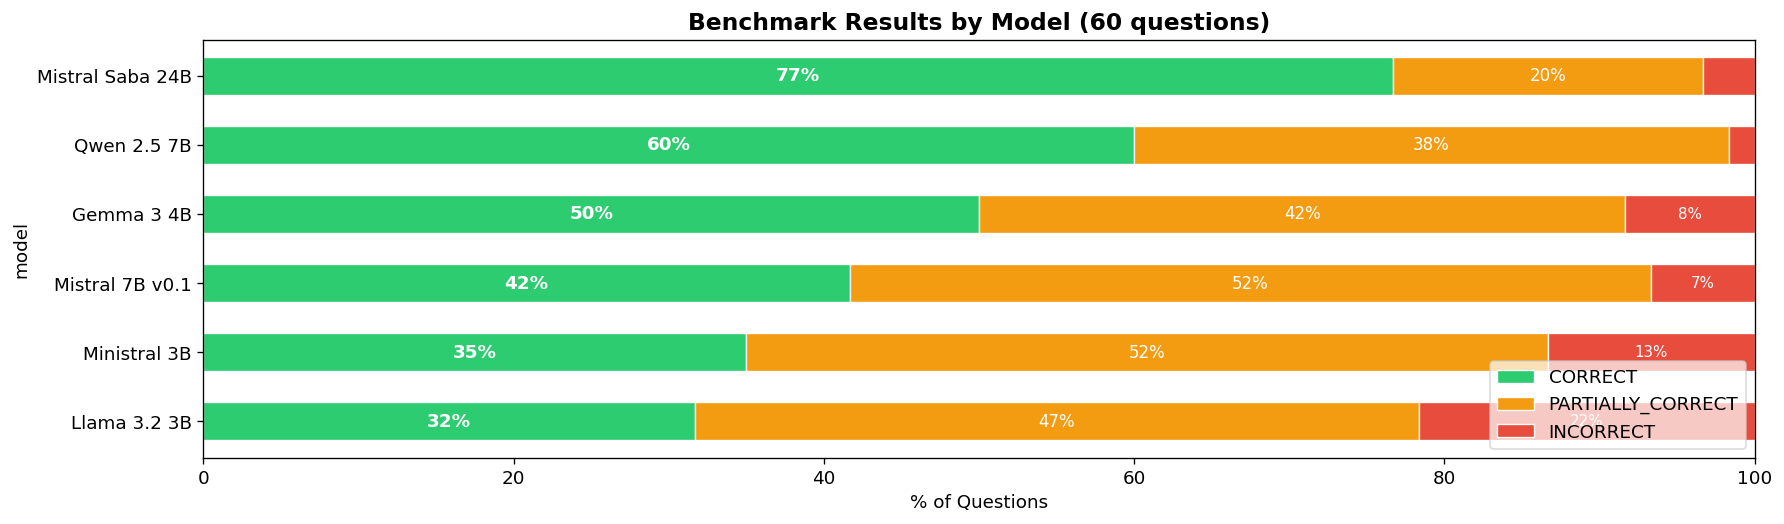

In [ ]:
pct = summary[['CORRECT', 'PARTIALLY_CORRECT', 'INCORRECT']].div(summary['total'], axis=0) * 100
colors = ['#2ecc71', '#f39c12', '#e74c3c']
fig, ax = plt.subplots(figsize=(10, 4.5))
pct.plot(
    kind='barh', stacked=True, color=colors, width=0.55, edgecolor='white', linewidth=0.8, ax=ax
)

for i, (idx, row) in enumerate(pct.iterrows()):
    c = row['CORRECT']
    p = row['PARTIALLY_CORRECT']
    inc = row['INCORRECT']
    if c > 5:
        ax.text(c / 2, i, f'{c:.0f}%', ha='center', va='center', fontweight='bold', fontsize=11, color='white')
    if p > 5:
        ax.text(c + p / 2, i, f'{p:.0f}%', ha='center', va='center', fontsize=10, color='white')
    if inc > 4:
        ax.text(c + p + inc / 2, i, f'{inc:.0f}%', ha='center', va='center', fontsize=9, color='white')

ax.set_xlabel('% of Questions')
ax.set_title('Benchmark Results by Model (60 questions)', fontsize=14, fontweight='bold')
ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.25), ncol=3, framealpha=0.7)
ax.set_xlim(0, 100)
ax.invert_yaxis()
fig.tight_layout()
plt.show()

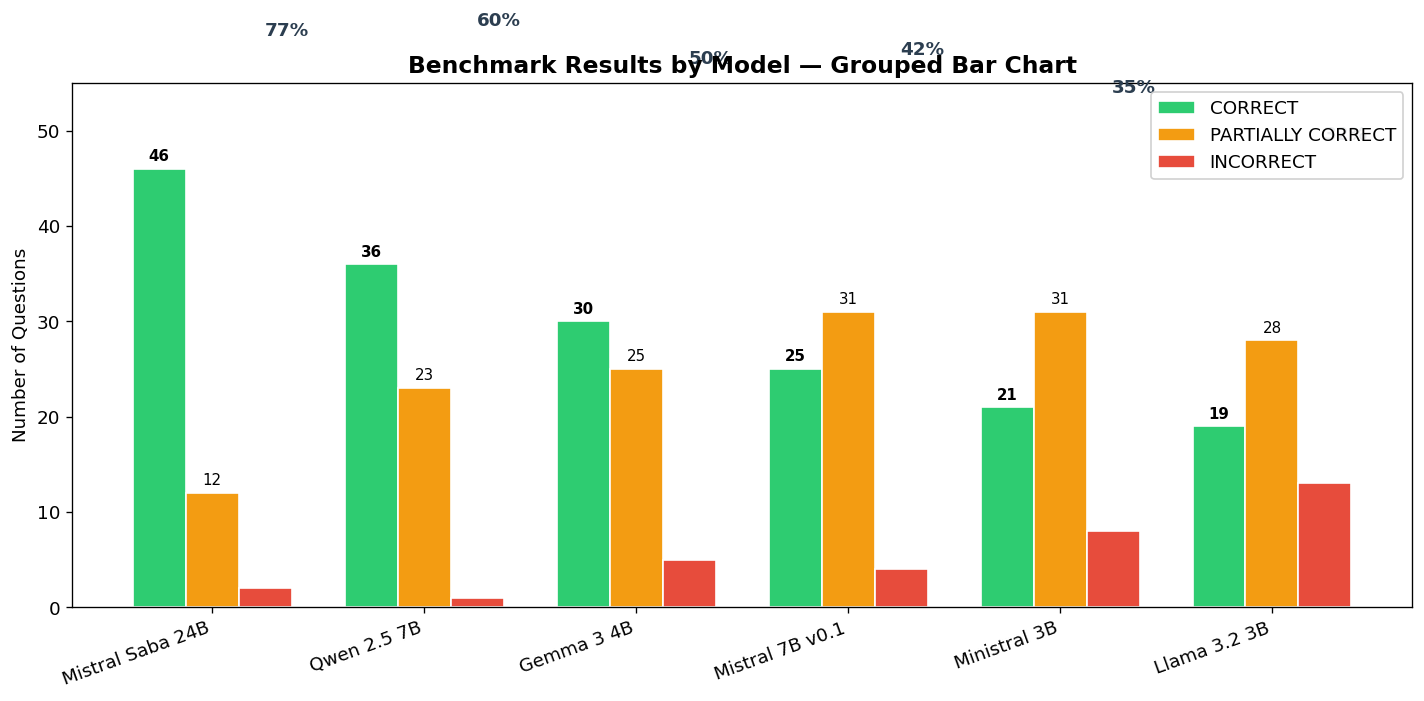

In [59]:
fig, ax = plt.subplots(figsize=(12, 6))

order = summary.index.tolist()
plot_df = summary[['CORRECT', 'PARTIALLY_CORRECT', 'INCORRECT']].loc[order]

x = np.arange(len(order))
width = 0.25

bars1 = ax.bar(x - width, plot_df['CORRECT'], width, label='CORRECT', color='#2ecc71', edgecolor='white')
bars2 = ax.bar(x, plot_df['PARTIALLY_CORRECT'], width, label='PARTIALLY CORRECT', color='#f39c12', edgecolor='white')
bars3 = ax.bar(x + width, plot_df['INCORRECT'], width, label='INCORRECT', color='#e74c3c', edgecolor='white')

for bar in bars1:
    if bar.get_height() > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{int(bar.get_height())}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')
for bar in bars2:
    if bar.get_height() > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{int(bar.get_height())}',
                ha='center', va='bottom', fontsize=9)
for bar in bars3:
    if bar.get_height() > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{int(bar.get_height())}',
                ha='center', va='bottom', fontsize=9, color='#c0392b')

ax.set_xticks(x)
ax.set_xticklabels(order, rotation=20, ha='right')
ax.set_ylabel('Number of Questions')
ax.set_title('Benchmark Results by Model — Grouped Bar Chart', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', framealpha=0.9)
ax.set_ylim(0, max(plot_df['CORRECT'].max(), plot_df['PARTIALLY_CORRECT'].max()) + 8)
plt.tight_layout()
plt.show()

/var/folders/s5/jhfb41cd5gdbmbrnjx67_l100000gn/T/ipykernel_88419/1331066449.py:13: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '72.7' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  pivot_pct.loc[level] = (pivot.loc[level] / difficulty_totals[level] * 100).round(1)
/var/folders/s5/jhfb41cd5gdbmbrnjx67_l100000gn/T/ipykernel_88419/1331066449.py:13: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '45.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  pivot_pct.loc[level] = (pivot.loc[level] / difficulty_totals[level] * 100).round(1)
/var/folders/s5/jhfb41cd5gdbmbrnjx67_l100000gn/T/ipykernel_88419/1331066449.py:13: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '72.7' 

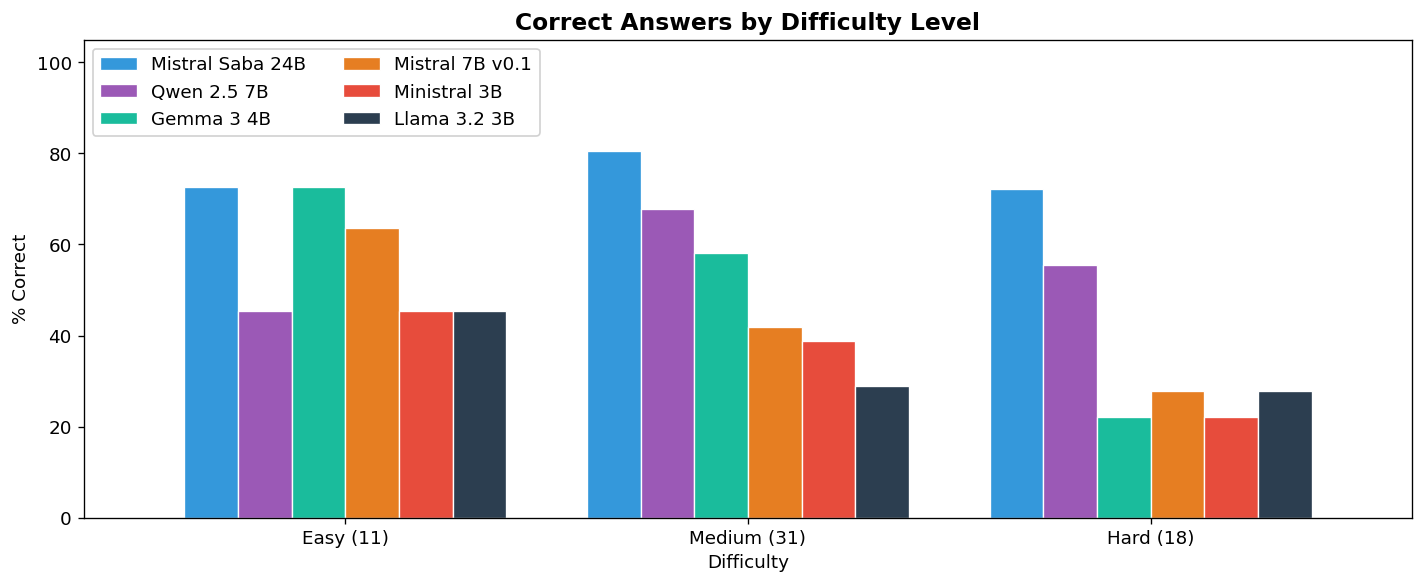

In [60]:
difficulty_totals = {'easy': 11, 'medium': 31, 'hard': 18}

pivot = df.pivot_table(
    index='classification', columns='model', values='evaluation',
    aggfunc=lambda x: (x == 'CORRECT').sum()
).fillna(0).astype(int)

pivot = pivot[order]
pivot = pivot.reindex(['easy', 'medium', 'hard'])

pivot_pct = pivot.copy()
for level in ['easy', 'medium', 'hard']:
    pivot_pct.loc[level] = (pivot.loc[level] / difficulty_totals[level] * 100).round(1)

fig, ax = plt.subplots(figsize=(12, 5))
pivot_pct.plot(kind='bar', ax=ax, width=0.8, edgecolor='white', linewidth=0.8,
               color=['#3498db', '#9b59b6', '#1abc9c', '#e67e22', '#e74c3c', '#2c3e50'])

ax.set_xlabel('Difficulty')
ax.set_ylabel('% Correct')
ax.set_title('Correct Answers by Difficulty Level', fontsize=14, fontweight='bold')
ax.legend(loc='upper left', framealpha=0.9, ncol=2)
ax.set_xticklabels(['Easy (11)', 'Medium (31)', 'Hard (18)'], rotation=0)
ax.set_ylim(0, 105)
plt.tight_layout()
plt.show()

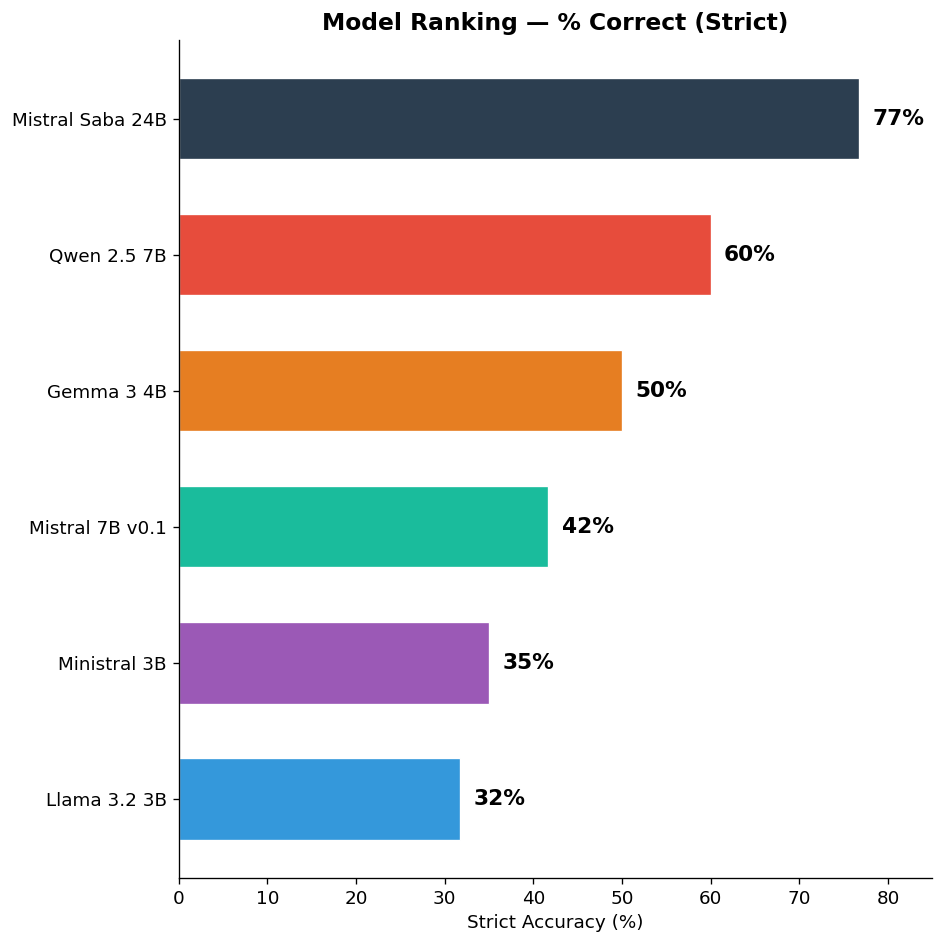

In [61]:
fig, ax = plt.subplots(figsize=(8, 8))

results = summary['correct_pct'].sort_values()
bars = ax.barh(results.index, results.values, color=['#3498db', '#9b59b6', '#1abc9c', '#e67e22', '#e74c3c', '#2c3e50'],
               edgecolor='white', linewidth=0.8, height=0.6)

for bar, val in zip(bars, results.values):
    ax.text(bar.get_width() + 1.5, bar.get_y() + bar.get_height()/2, f'{val:.0f}%',
            ha='left', va='center', fontweight='bold', fontsize=13)

ax.set_xlim(0, 85)
ax.set_xlabel('Strict Accuracy (%)')
ax.set_title('Model Ranking — % Correct (Strict)', fontsize=14, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

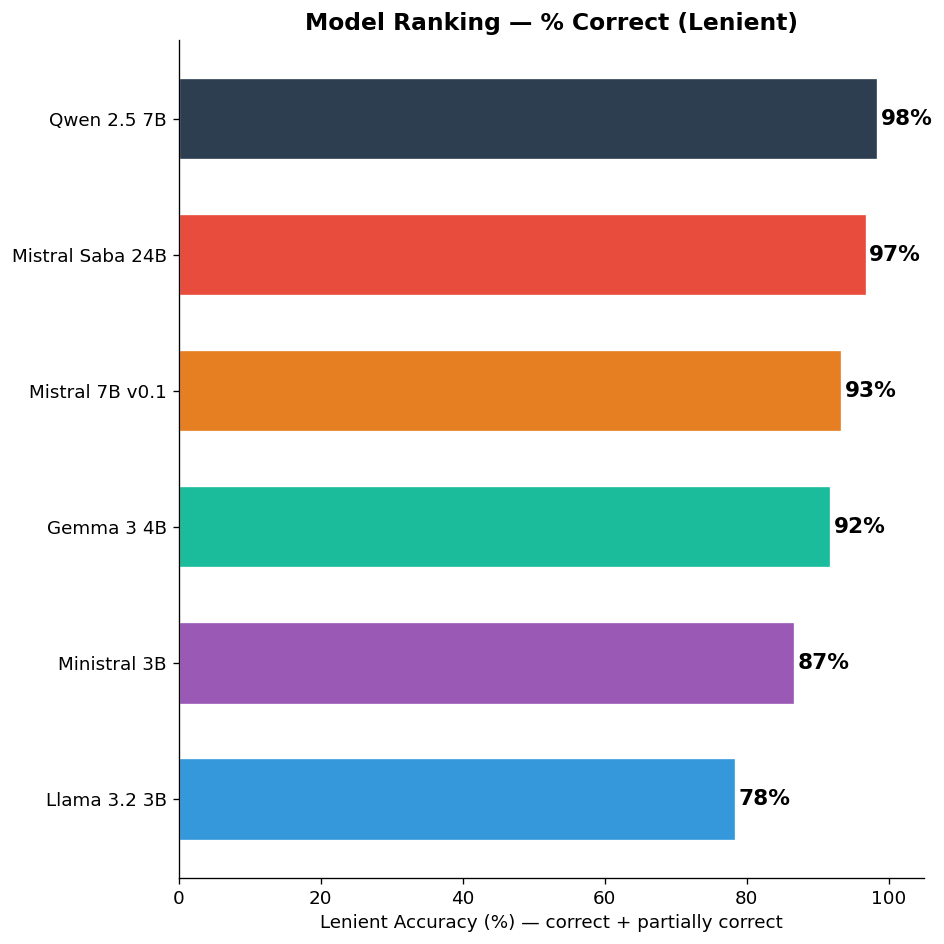

In [62]:
summary['lenient_pct'] = ((summary['CORRECT'] + summary['PARTIALLY_CORRECT']) / summary['total'] * 100).round(1)

fig, ax = plt.subplots(figsize=(8, 8))

results = summary['lenient_pct'].sort_values()
bars = ax.barh(results.index, results.values, color=['#3498db', '#9b59b6', '#1abc9c', '#e67e22', '#e74c3c', '#2c3e50'],
               edgecolor='white', linewidth=0.8, height=0.6)

for bar, val in zip(bars, results.values):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, f'{val:.0f}%',
            ha='left', va='center', fontweight='bold', fontsize=13)

ax.set_xlim(0, 105)
ax.set_xlabel('Lenient Accuracy (%) — correct + partially correct')
ax.set_title('Model Ranking — % Correct (Lenient)', fontsize=14, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

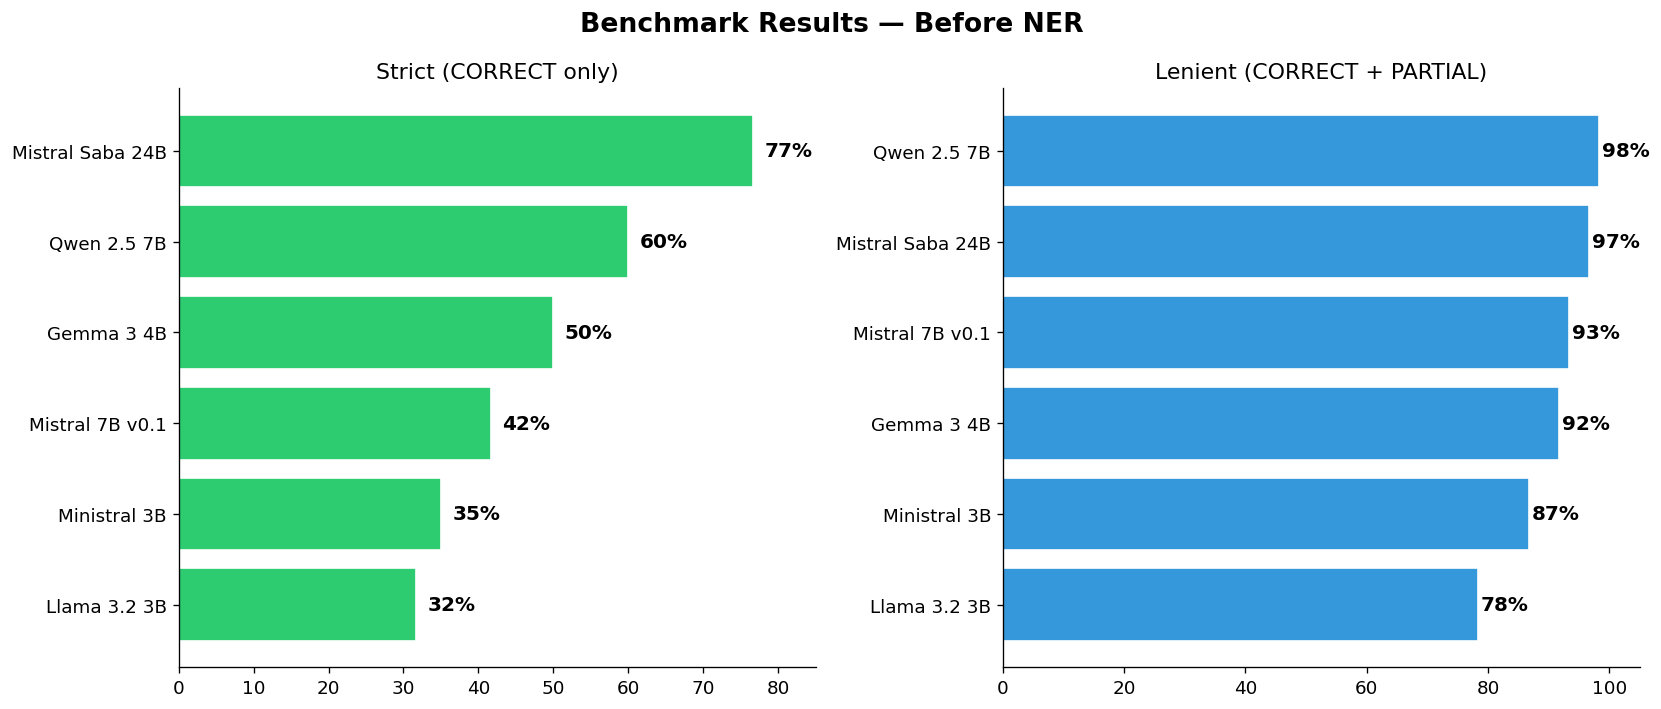

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

strict = summary['correct_pct'].sort_values()
lenient = summary['lenient_pct'].sort_values()

axes[0].barh(strict.index, strict.values, color='#2ecc71', edgecolor='white')
for i, (label, val) in enumerate(strict.items()):
    axes[0].text(val + 1.5, i, f'{val:.0f}%', va='center', fontweight='bold', fontsize=12)
axes[0].set_title('Strict (CORRECT only)')
axes[0].set_xlim(0, 85)

axes[1].barh(lenient.index, lenient.values, color='#3498db', edgecolor='white')
for i, (label, val) in enumerate(lenient.items()):
    axes[1].text(val + 0.5, i, f'{val:.0f}%', va='center', fontweight='bold', fontsize=12)
axes[1].set_title('Lenient (CORRECT + PARTIAL)')
axes[1].set_xlim(0, 105)

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Benchmark Results — Before NER', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## Summary

Baseline benchmark results across 6 small models (60 questions each), evaluated by GPT-5.4.

**Key findings:**
- **Mistral Saba (24B)** leads at 76.7% strict accuracy despite being a regional model
- **Qwen 2.5 7B** is the best actual ≤7B model at 60.0% strict, 98.3% lenient (only 1 wrong)
- **Llama 3.2 3B** trails at 31.7% — high error rate on complex questions
- All models benefit significantly from partial credit (lenient scores 90%+ for top 4 models)